In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.io as sio

In [210]:
import colour
from colour.plotting import *
colour_style()

{'figure.figsize': (12.8, 7.2),
 'figure.dpi': 100,
 'savefig.dpi': 100,
 'savefig.bbox': 'standard',
 'axes.titlesize': 'x-large',
 'axes.labelsize': 'larger',
 'legend.fontsize': 'small',
 'xtick.labelsize': 'medium',
 'ytick.labelsize': 'medium',
 'text.color': '#111111',
 'xtick.top': False,
 'xtick.bottom': True,
 'ytick.right': False,
 'ytick.left': True,
 'xtick.minor.visible': True,
 'ytick.minor.visible': True,
 'xtick.direction': 'out',
 'ytick.direction': 'out',
 'xtick.major.size': 6.25,
 'xtick.minor.size': 3.75,
 'ytick.major.size': 6.25,
 'ytick.minor.size': 3.75,
 'xtick.major.width': 1,
 'xtick.minor.width': 1,
 'ytick.major.width': 1,
 'ytick.minor.width': 1,
 'axes.linewidth': 1,
 'axes.edgecolor': '#333333',
 'axes.titlepad': 7.5,
 'axes.facecolor': '#F5F5F5',
 'axes.grid': True,
 'axes.grid.which': 'major',
 'axes.grid.axis': 'both',
 'axes.axisbelow': True,
 'grid.linewidth': 0.5,
 'grid.linestyle': '--',
 'grid.color': '#D5D5D5',
 'legend.frameon': True,
 'legend

In [211]:
import os
import numpy as np


def _interpolate_if_necessary(x, y):
    x = np.asarray(x, dtype=float).ravel()
    y = np.asarray(y, dtype=float)

    if y.ndim == 1:
        y = y.reshape(-1, 1)

    if np.max(np.diff(x)) > 1:
        xi = np.arange(x[0], x[-1] + 1, 1.0)
        yi = np.column_stack([np.interp(xi, x, y[:, k]) for k in range(y.shape[1])])
        return xi, yi

    return x, y


def _common_domain(x1, y1, x2, y2):
    x1, y1 = _interpolate_if_necessary(x1, y1)
    x2, y2 = _interpolate_if_necessary(x2, y2)

    start = max(x1[0], x2[0])
    end = min(x1[-1], x2[-1])
    xc = np.arange(start, end + 1, 1.0)

    x1_int = np.round(x1).astype(int)
    x2_int = np.round(x2).astype(int)
    xc_int = np.round(xc).astype(int)

    y1c = y1[np.isin(x1_int, xc_int), :]
    y2c = y2[np.isin(x2_int, xc_int), :]

    return xc, y1c, y2c


def _thXYZToxyY(XYZ):
    XYZ = np.asarray(XYZ, dtype=float)
    if XYZ.ndim != 2 or XYZ.shape[0] != 3:
        raise ValueError("XYZ values must be given as a 3xN array.")

    X = XYZ[0, :]
    Y = XYZ[1, :]
    Z = XYZ[2, :]

    sum_XYZ = X + Y + Z
    x = X / sum_XYZ
    y = Y / sum_XYZ

    return np.vstack([x, y, Y])


def mg_spectra2xyY(spectra, which_color_matching_function="cie1931", cmf_dir="ModelMetrics_ForRob"):
    """Convert spectra to xy chromaticity values and luminance Y.

    Parameters
    ----------
    spectra : array_like
        2D array with wavelengths in column 0 and one or more spectra in remaining columns.
    which_color_matching_function : str
        One of 'judd', 'cie1931', or 'cie1964' (case-insensitive variants supported).
    cmf_dir : str
        Directory containing CMF files (e.g., ciexyz31_1.txt).

    Returns
    -------
    dict
        Keys: x, y, z, X, Y, Z, xyY, XYZ
    """
    cmf_map = {
        "judd": "ciexyzj.txt",
        "cie1931": "ciexyz31_1.txt",
        "cie1964": "ciexyz64_1.txt",
    }

    cmf_key = which_color_matching_function.lower()
    if cmf_key not in cmf_map:
        raise ValueError(f"Unknown color matching function {which_color_matching_function}.")

    cmf_path = os.path.join(cmf_dir, cmf_map[cmf_key])
    wavelength, x_bar, y_bar, z_bar = np.loadtxt(cmf_path, delimiter=",", unpack=True)

    x1 = wavelength
    y1 = np.column_stack([x_bar, y_bar, z_bar])

    spectra = np.asarray(spectra, dtype=float)
    if spectra.ndim != 2 or spectra.shape[1] < 2:
        raise ValueError("spectra must be a 2D array with wavelengths in col 0 and spectra in col 1+.")

    wavelength_spectra = spectra[:, 0]
    spectra_measured = spectra[:, 1:]

    wavelength_common, xyz_common, spectra_measured_common = _common_domain(
        x1, y1, wavelength_spectra, spectra_measured
    )

    XYZ = 683.0 * spectra_measured_common.T @ xyz_common
    xyY = _thXYZToxyY(XYZ.T).T

    return {
        "x": xyY[:, 0],
        "y": xyY[:, 1],
        "z": 1.0 - xyY[:, 0] - xyY[:, 1],
        "X": XYZ[:, 0],
        "Y": XYZ[:, 1],
        "Z": XYZ[:, 2],
        "xyY": xyY,
        "XYZ": XYZ,
        "wavelength_common": wavelength_common,
    }


In [27]:
all_rgbs = sio.loadmat("ModelMetrics_ForRob/AllCubes.mat")
all_rgbs_144 = sio.loadmat("ColorPatchMetric/AllCubes_144.mat")
all_rgbs_732 = sio.loadmat("ColorPatchMetric/AllCubes_732.mat")

sc_model_data_144 = sio.loadmat("ColorPatchMetric/BrightnessModel_144Patches.mat")
sc_model_data_864 = sio.loadmat("ColorPatchMetric/BrightnessModel_864Patches.mat")

In [241]:
brightnesses_144 = sc_model_data_144['BrightnessModel']
brightnesses_864 = sc_model_data_864['BrightnessModel']

In [34]:
all_cubes = all_rgbs['AllCubes']
chips_144 = all_rgbs_144['AllCubes']
chips_732 = all_rgbs_732['AllCubes']

In [354]:
gamut = sio.loadmat("ModelMetrics_ForRob/oled_gamut.mat")['oled_gamut']
rgb_mode = sio.loadmat("ModelMetrics_ForRob/oled_rgb_mode.mat")['data']
gammas = sio.loadmat("ModelMetrics_ForRob/oled_primary_gammas.mat")

In [355]:
gains = gammas['gains']
gammas = gammas['gammas']

In [321]:
GAMMAS = np.array([2.1452, 2.1489, 2.0831]) # MT 20/1/20
rgamma = GAMMAS[0]
ggamma = GAMMAS[1]
bgamma = GAMMAS[2]

corrRGB = np.zeros_like(all_cubes, dtype=np.uint8)
corrRGB[:, :, 0] = ((all_cubes[:, :, 0] ** (1.0/rgamma)) * 255).astype(np.uint8)
corrRGB[:, :, 1] = ((all_cubes[:, :, 1] ** (1.0/ggamma)) * 255).astype(np.uint8)
corrRGB[:, :, 2] = ((all_cubes[:, :, 2] ** (1.0/bgamma)) * 255).astype(np.uint8)

# corrRGB_reshaped = corrRGB.reshape(-1, 3).astype(np.float64) # 144 x 3
corrRGB_reshaped = np.zeros((144, 3))
for i in range(12):
    for j in range(12):
        corrRGB_reshaped[i*12 + j, :] = corrRGB[j, i, :]

OLED_gammas = gammas[0, :]

RedPrimary = rgb_mode[0, 8][0]['spectralData'][0].squeeze()
GreenPrimary = rgb_mode[0, 16][0]['spectralData'][0].squeeze()
BluePrimary = rgb_mode[0, 24][0]['spectralData'][0].squeeze()

RGB_List = np.array([
    (corrRGB_reshaped[:, 0]/255) ** OLED_gammas[0],
    (corrRGB_reshaped[:, 1]/255) ** OLED_gammas[1],
    (corrRGB_reshaped[:, 2]/255) ** OLED_gammas[2],
])

all_reds = np.array([RedPrimary * RGB_List[0, i] for i in range(RGB_List.shape[1])])
all_greens = np.array([GreenPrimary * RGB_List[1, i] for i in range(RGB_List.shape[1])])
all_blues = np.array([BluePrimary * RGB_List[2, i] for i in range(RGB_List.shape[1])])

AllSpectra = all_reds + all_greens + all_blues

wl = np.arange(380, 781)

In [349]:
max_white_s = rgb_mode[0, 25][0]['spectralData'][0].squeeze()

cmfs = colour.MSDS_CMFS["CIE 1931 2 Degree Standard Observer"]
illuminant = colour.SDS_ILLUMINANTS["D65"]
white_data = {int(wl[j]): max_white_s[j] for j in range(len(wl))}
white_sd = colour.SpectralDistribution(white_data, name="Sample")
colour_white_XYZ = colour.sd_to_XYZ(white_sd)

white_XYZ = mg_spectra2xyY(np.vstack([wl, max_white_s]).T)['XYZ']

L_A = 0.2 * np.sum(gamut[2, :]) # adapting luminance: 20% white
XYZ_w = white_XYZ
Y_b = rgb_mode[0, 0][0]['Y'][0][0][0] 
surround = colour.VIEWING_CONDITIONS_sCAM["Dim"]

rob_sucs_Is = np.zeros(AllSpectra.shape[0])
rob_scam_Qs = np.zeros(AllSpectra.shape[0])
colour_rob_scam_Qs = np.zeros(AllSpectra.shape[0])
rob_lab_Ls = np.zeros(AllSpectra.shape[0])
for i in range(AllSpectra.shape[0]):
    spectrum = AllSpectra[i, :] 

    XYZ = mg_spectra2xyY(np.vstack([wl, spectrum]).T)['XYZ']

    sUCS = colour.XYZ_to_sUCS(XYZ)
    rob_sucs_Is[i] = sUCS[0][0]

    sCAM = colour.XYZ_to_sCAM(XYZ, XYZ_w, L_A, Y_b, surround, discount_illuminant=True)
    rob_scam_Qs[i] = sCAM.Q[0]

    colour_sCAM = colour.XYZ_to_sCAM(XYZ, colour_white_XYZ, L_A, Y_b, surround, discount_illuminant=True)
    colour_rob_scam_Qs[i] = colour_sCAM.Q[0]

    LAB = colour.XYZ_to_Lab(XYZ, XYZ_w)
    rob_lab_Ls[i] = LAB[0][0]

In [341]:
sc_sucs_Is_d65 = brightnesses_144['Lightess_sUCS_D65'][0][0].squeeze()
sc_sucs_Is_srgb = brightnesses_144['Lightess_sUCS_sRGB'][0][0].squeeze()
sc_scam_Qs_d65 = brightnesses_144['Q_sCAM_D65'][0][0].squeeze()
sc_scam_Qs_srgb = brightnesses_144['Q_sCAM_sRGB'][0][0].squeeze()
sc_lab_Ls = brightnesses_144['Lstar'][0][0].squeeze()

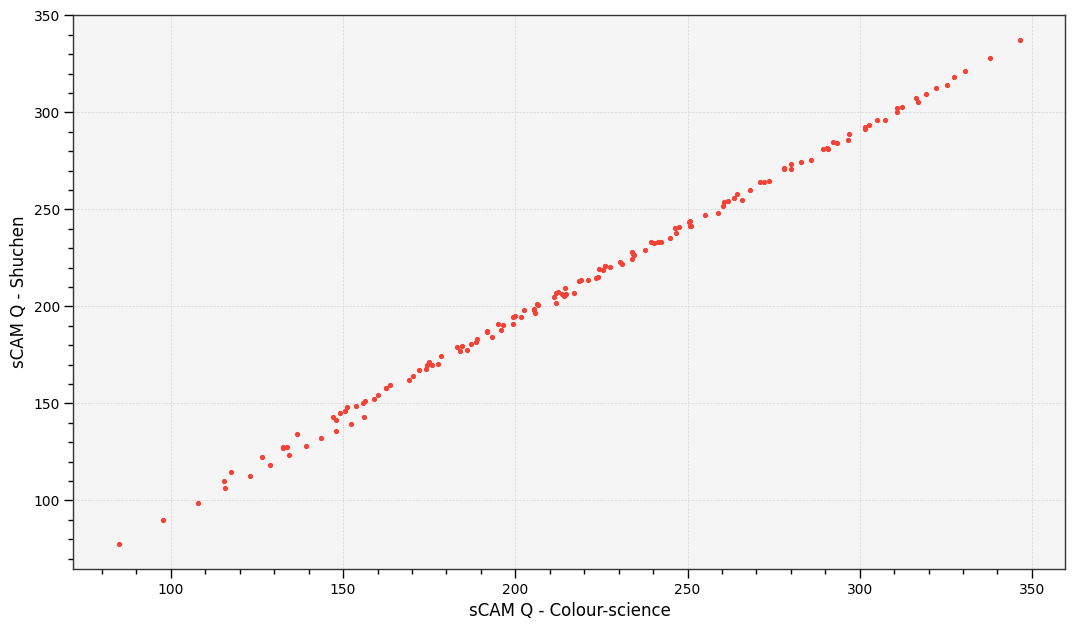

In [348]:
plt.plot(rob_scam_Qs, sc_scam_Qs_srgb, "o", label="sCAM Q")
plt.xlabel("sCAM Q - Colour-science")
plt.ylabel("sCAM Q - Shuchen")
plt.show()

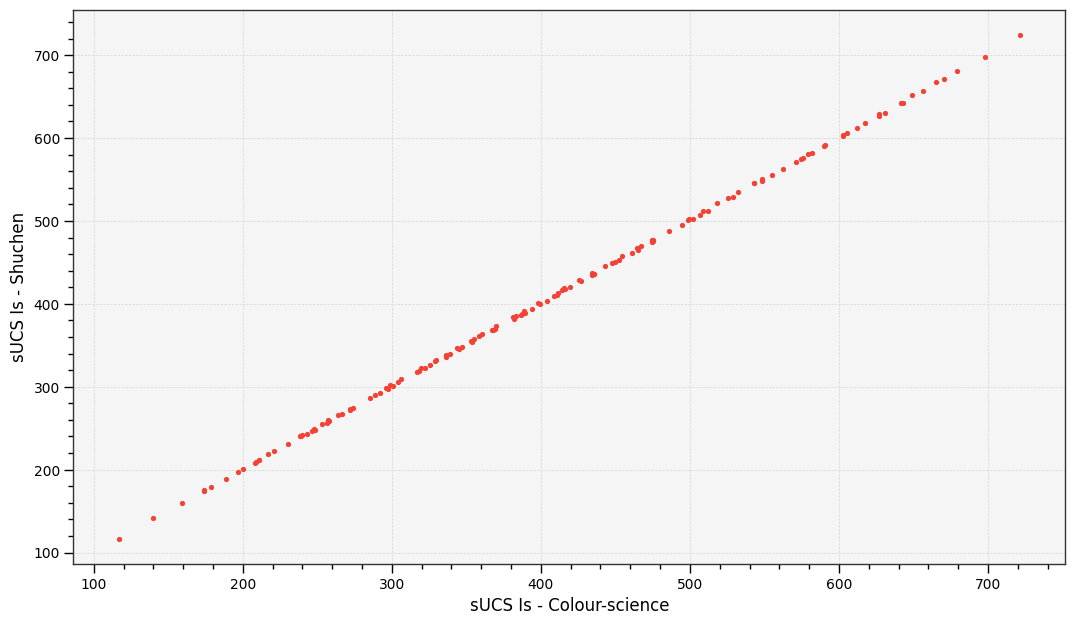

In [351]:
plt.plot(rob_sucs_Is, sc_sucs_Is_d65, 'o', label='sUCS D65')
plt.xlabel("sUCS Is - Colour-science")
plt.ylabel("sUCS Is - Shuchen")
plt.show()